# Fase 3 — Detección de Anomalías (03_anomaly_detection.ipynb)

**Objetivo:** identificar ciclos operativos que se desvían del comportamiento normal del sistema hidráulico, usando solo los 73 features escalares exportados por la Fase 2 — sin acceso a los sensores crudos. Se implementan dos detectores complementarios: **distancia de Mahalanobis** (modelo estadístico paramétrico, asume gaussianidad multivariante) y un **autoencoder denso** (modelo no paramétrico que aprende la distribución normal por reconstrucción). Ambos se entrenan exclusivamente sobre ciclos "normales" (todos los componentes en estado óptimo simultáneamente) y producen una puntuación de anomalía continua por ciclo. El notebook sigue el patrón **Decisión → Código → Interpretación** de las fases anteriores.

## Hallazgos previos que condicionan esta fase

1. **`PS3_peak_s` tiene η²=0.977 con `valve_condition`** (Sección 2 del Notebook 2) — en un espacio de 73 dimensiones, esta feature dominará cualquier distancia que no esté normalizada por varianza; el escalado previo al cálculo de distancias es crítico.
2. **`cooler_condition` domina la varianza de casi todas las features** (Secciones 1, 3 y 4 del Notebook 2) — los ciclos con enfriador degradado aparecerán como "anómalos" incluso si el resto de componentes están en estado óptimo; el análisis de resultados debe desglosar las puntuaciones por target, no solo mirar una tasa de detección global.
3. **El conjunto de entrenamiento completo tiene 1157 ciclos, pero ese no es el número que importa para esta fase.** Ambos detectores (Mahalanobis y autoencoder) se entrenan exclusivamente sobre los ciclos "normales" — la intersección de los 4 óptimos, que es **una única combinación** dentro del diseño factorial de 144 (Sección 2 del EDA), no una fracción representativa de los 1157. Ese subconjunto es casi con certeza mucho más pequeño, y su tamaño real condiciona si ambos métodos son siquiera viables tal cual: Mahalanobis necesita invertir una matriz de covarianza 73×73, lo que requiere al menos 73 muestras independientes para no ser singular; un autoencoder con miles de parámetros entrenado con pocos ciclos normales corre un riesgo real de sobreajuste severo. Esta sección calcula el número exacto antes de asumir que cualquiera de los dos enfoques funciona sin ajustes.


## 0. Imports, carga y definición de normalidad


**Decisión — tres decisiones en esta sección:**

**Primera, los datos de entrada.** Se cargan directamente los cuatro Parquet exportados por el Notebook 2 — `X_train`, `X_test`, `y_train`, `y_test`. No se reconstruye nada desde los sensores crudos: las 73 features ya incluyen toda la señal discriminativa identificada en la Fase 2, y un autoencoder con entrada `[73→64→32→16]` es una arquitectura razonable; si la entrada fueran los sensores crudos (>40.000 dimensiones), esa arquitectura sería absurda.

**Segunda, la definición de "ciclo normal".** Para entrenar un detector no supervisado se necesita un subconjunto de referencia que represente el estado sano del sistema. Se define como normal todo ciclo donde los cuatro componentes están simultáneamente en su estado óptimo: `cooler_condition=100` (sin degradación), `valve_condition=100` (sin degradación), `pump_leakage=0` (sin fuga), `accumulator_pressure=130` (presión nominal). Esta intersección es la única clase donde no hay degradación activa en ningún componente. Se aplica sobre `y_train` (nunca sobre `y_test`, que permanece sellado) para extraer `X_normal_train` — el conjunto de referencia sobre el que se entrenan ambos detectores. Como se advirtió en la introducción, este es el número que realmente importa para esta fase, no los 1157 del training set completo.

**Tercera, el escalado.** Las 73 features tienen escalas muy distintas (presiones en bar, temperaturas en °C, eficiencia sin unidades). La distancia de Mahalanobis tiene en cuenta la covarianza, así que no necesita escalado previo para ser matemáticamente correcta — pero el autoencoder sí lo necesita para converger de forma estable. El `StandardScaler` se ajusta (`fit`) exclusivamente sobre `X_normal_train` y se aplica (`transform`) a los tres conjuntos (normal train, train completo, test) — ajustar sobre cualquier otro conjunto introduciría fuga de la distribución de ciclos degradados en la referencia de normalidad.


In [1]:
import numpy as np  # operaciones numéricas vectorizadas
import pandas as pd  # DataFrames para features y targets
from pathlib import Path  # manejo de rutas multiplataforma

from sklearn.preprocessing import StandardScaler  # escalado, se usa ya en esta sección
from sklearn.covariance import EmpiricalCovariance  # reservado para la Sección 1 (Mahalanobis) — no se usa todavía
from scipy.spatial.distance import mahalanobis  # idem — reservado para la Sección 1

# El autoencoder (Sección 2) usará torch o tensorflow; no se importa todavía, no hace falta en esta sección.

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"  # mismos archivos que exportó el Notebook 2

# ── Carga de los 4 Parquet exportados por la Fase 2 ──
X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_test = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")
y_test = pd.read_parquet(PROCESSED_DIR / "y_test.parquet")

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

# ── Definición de "ciclo normal": intersección de los 4 componentes en su estado óptimo ──
normal_mask_train = (
    (y_train["cooler_condition"] == 100)
    & (y_train["valve_condition"] == 100)
    & (y_train["pump_leakage"] == 0)
    & (y_train["accumulator_pressure"] == 130)
)
X_normal_train = X_train[normal_mask_train.values].reset_index(drop=True)  # solo sobre y_train — y_test permanece sellado
print(f"\nCiclos normales en train: {len(X_normal_train)} ({100 * len(X_normal_train) / len(X_train):.2f}% del training set)")

# ── Escalado: fit SOLO sobre X_normal_train, transform sobre los 3 conjuntos ──
scaler = StandardScaler()
X_normal_scaled = pd.DataFrame(scaler.fit_transform(X_normal_train), columns=X_normal_train.columns)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

for name, df in [("X_normal_scaled", X_normal_scaled), ("X_train_scaled", X_train_scaled), ("X_test_scaled", X_test_scaled)]:
    assert not df.isnull().values.any(), f"NaN encontrado en {name} tras el escalado"
print("Verificación de NaN tras escalado: OK en los 3 conjuntos.")

# ── Verificación de escala: media≈0, std≈1 en X_normal_scaled (el conjunto sobre el que se ajustó el scaler) ──
# ddof=0 explícito: StandardScaler usa desviación estándar poblacional (entre N, no N-1) internamente.
# Con pandas.std() por defecto (ddof=1) el resultado NO daría exactamente 1 y parecería un error sin serlo.
scale_check = pd.DataFrame(
    {"media": X_normal_scaled.iloc[:, :5].mean(), "std (ddof=0)": X_normal_scaled.iloc[:, :5].std(ddof=0)}
)
print("\nVerificación de escala (primeras 5 columnas de X_normal_scaled):")
print(scale_check.round(4))


X_train: (1157, 73) | X_test: (290, 73)
y_train: (1157, 4) | y_test: (290, 4)

Ciclos normales en train: 8 (0.69% del training set)
Verificación de NaN tras escalado: OK en los 3 conjuntos.

Verificación de escala (primeras 5 columnas de X_normal_scaled):
                      media  std (ddof=0)
PS1_mean                0.0           1.0
PS1_std                -0.0           1.0
PS1_mean_first_half    -0.0           1.0
PS1_mean_second_half   -0.0           1.0
PS2_mean               -0.0           1.0


**Interpretación:**

**La fracción es mucho menor de lo esperado en términos absolutos, y confirma el problema anticipado en la introducción.** `X_normal_train` tiene **8 ciclos** — el 0.69% del training set (1157 ciclos). Coincide, de hecho, casi exactamente con 1/144≈0.694%: la intersección de los 4 óptimos es una única combinación dentro del diseño factorial de 144 (Sección 2 del EDA), y recibió una fracción de ciclos proporcional a cualquier otra celda — ni sobre ni sub-representada por diseño. El problema no es que el filtrado haya sido desproporcionado; es que "1 combinación de 144" es, aritméticamente, muy poco en términos absolutos (Sección 2 del EDA ya documentó un mínimo de 9 réplicas por combinación en la población filtrada de 1447 ciclos; tras el split 80/20 esta combinación concreta quedó con 8 en train y 2 en test). No es un error del pipeline — es la consecuencia directa de que "todos los componentes óptimos a la vez" es solo una celda entre 144, no una categoría con peso proporcional al resto de la población.

**Esto hace inviable la distancia de Mahalanobis con covarianza empírica estándar, tal como está planteada.** Con 73 features y solo 8 muestras, la matriz de covarianza 73×73 tiene, como mucho, rango 7 (rango ≤ n-1 para una matriz de covarianza estimada a partir de n observaciones) — es matemáticamente singular, no invertible, sin importar qué tan bien escalados estén los datos. `EmpiricalCovariance` de scikit-learn no fallará al hacer `.fit()`, pero cualquier intento de invertir esa matriz (necesario para la distancia de Mahalanobis) fallará o producirá resultados numéricamente inestables. La Sección 1 no puede usar covarianza empírica estándar sobre las 73 dimensiones completas — necesitará una alternativa: estimadores con regularización/shrinkage (`sklearn.covariance.LedoitWolf` o `ShrunkCovariance`, que garantizan una matriz invertible incluso con n<p), o una reducción de dimensionalidad previa (p. ej. PCA sobre `X_normal_scaled` reteniendo muchas menos de 8 componentes) antes de calcular la distancia. Se decidirá el enfoque concreto al construir esa sección.

**El autoencoder enfrenta el mismo problema, de forma menos formalizable pero igual de real.** Una red `[73→64→32→16]` tiene miles de parámetros; entrenarla con 8 ejemplos no tiene forma de generalizar — memorizará esos 8 ciclos casi con certeza. La Sección 2 tendrá que abordarlo explícitamente (arquitectura mucho más pequeña, fuerte regularización, o repensar qué conjunto de entrenamiento usar) en vez de aplicar la arquitectura del prompt original tal cual.

**La verificación de escala es correcta:** media≈0.0 y std≈1.0 (con `ddof=0`, coincidiendo con la convención interna de `StandardScaler`) en las 5 columnas comprobadas — el `fit` sobre `X_normal_train` funcionó como se esperaba, con independencia de que la muestra sea pequeña. El escalado en sí no tiene ningún problema; el problema es exclusivamente de tamaño de muestra para los pasos que vienen después.


## 1. Distancia de Mahalanobis (LedoitWolf)

**El problema de rango.** La distancia de Mahalanobis entre un ciclo x y la referencia normal es d(x,μ) = √[(x−μ)ᵀ Σ⁻¹ (x−μ)], donde μ es la media de `X_normal_train` y Σ es la covarianza de la distribución normal. El problema no es solo que n=8 sea "pequeño": es que la matriz de covarianza muestral S estimada con n observaciones tiene rango máximo n−1 = 7. Con p=73 features, S tiene 66 valores propios exactamente iguales a cero — es singular por construcción, sin importar la naturaleza de los datos. La inversión necesaria para la distancia de Mahalanobis es matemáticamente imposible sobre S sin regularización.

**LedoitWolf como solución.** El estimador LedoitWolf produce una versión regularizada de la covarianza: S̃ = (1−α)·S + α·(tr(S)/p)·I, donde α ∈ [0,1] es el coeficiente de shrinkage estimado analíticamente minimizando el error cuadrático esperado entre S̃ y la covarianza verdadera Σ. Con n=8 y p=73 (n≪p), cabe esperar que el valor óptimo de α esté cerca de 1: el estimador se acercaría más a una identidad escalada que a la covarianza muestral. Esto no sería un fallo — sería la consecuencia honesta de que 8 observaciones no contienen suficiente información para estimar p(p−1)/2 = 73×72/2 = 2.628 entradas de covarianza únicas. La matriz S̃ resultante es, en cualquier caso, definida positiva e invertible, y el coeficiente α (disponible como `.shrinkage_` en scikit-learn) indica cuánta estructura de correlación real fue posible estimar frente a cuánta es regularización pura.

**Qué mide realmente la distancia en este escenario.** Cuando α es alto (≈1), S̃ ≈ (tr(S)/p)·I, y la distancia de Mahalanobis se aproxima a la distancia euclídea estandarizada por la varianza promedio de los 8 ciclos normales — la estructura de correlación entre features queda mal estimada. Lo que sí queda bien definido es el centroide μ: la media de los 8 ciclos normales. La distancia resultante mide "alejamiento del centroide de los ciclos normales, ponderado por la varianza promedio observada" — una noción de anomalía más débil que la verdadera distancia de Mahalanobis, pero informativa y calculada de forma honesta, siempre que α resulte efectivamente alto.

**Umbral de referencia: χ²(p).** Bajo normalidad multivariante exacta y covarianza conocida, d²_M sigue una distribución χ² con p=73 grados de libertad (E[χ²(73)]=73, percentil 95 ≈94.0). Con n=8 y covarianza regularizada, esta conexión teórica es débil — el umbral χ²₀.₉₅(73) se calcula y se usa como referencia de orden de magnitud, no como un umbral calibrado. El análisis real no se basa en este umbral sino en la distribución empírica de las puntuaciones desglosada por target.


In [2]:
from sklearn.covariance import LedoitWolf  # estimador de covarianza regularizado, invertible incluso con n<p
from scipy.stats import chi2, spearmanr  # umbral de referencia chi^2(p) y correlacion de rangos

# ── Ajustar LedoitWolf sobre los 8 ciclos normales escalados ──
lw = LedoitWolf()
lw.fit(X_normal_scaled)
print(f"Coeficiente de shrinkage α = {lw.shrinkage_:.4f}")
if lw.shrinkage_ > 0.9:
    print("α > 0.9: la estimación de correlaciones entre features está dominada por la regularización, no por los datos.")

# ── Puntuaciones de Mahalanobis^2 (el método .mahalanobis() de sklearn ya devuelve la distancia AL CUADRADO) ──
maha2_normal = lw.mahalanobis(X_normal_scaled)
maha2_train = lw.mahalanobis(X_train_scaled)
maha2_test = lw.mahalanobis(X_test_scaled)
print(f"\nmaha2_normal: {maha2_normal.shape} | maha2_train: {maha2_train.shape} | maha2_test: {maha2_test.shape}")

# ── Umbral de referencia chi^2_0.95(73) ──
threshold_chi2 = chi2.ppf(0.95, df=X_train_scaled.shape[1])
print(f"\nUmbral de referencia χ²₀.₉₅(73) = {threshold_chi2:.2f}")

# ── Análisis sobre el training set ──
analysis_train = pd.DataFrame({"maha2_score": maha2_train})
for target in ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]:
    analysis_train[target] = y_train[target].values

print(f"\nMediana de maha2_score en los 8 ciclos normales (referencia): {np.median(maha2_normal):.4f}")
print(f"Mediana de maha2_score en todo el training set: {np.median(maha2_train):.4g}")
pct_over_threshold = 100 * (maha2_train > threshold_chi2).mean()
print(f"Porcentaje del training set por encima del umbral χ²₀.₉₅(73): {pct_over_threshold:.2f}%")

# ── Desglose por nivel de cooler_condition (de mayor a menor degradación) ──
print("\nMediana de maha2_score por cooler_condition (3=más degradado, 100=óptimo):")
print(analysis_train.groupby("cooler_condition")["maha2_score"].median().sort_index(ascending=True).to_string())

# ── Correlación de Spearman entre maha2_score y cada uno de los 4 targets ──
print("\nCorrelación de Spearman entre maha2_score y cada target (training set):")
for target in ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]:
    rho, p_value = spearmanr(analysis_train["maha2_score"], analysis_train[target])
    print(f"  {target}: ρ={rho:.4f}, p={p_value:.4g}")


Coeficiente de shrinkage α = 0.5632

maha2_normal: (8,) | maha2_train: (1157,) | maha2_test: (290,)

Umbral de referencia χ²₀.₉₅(73) = 93.95

Mediana de maha2_score en los 8 ciclos normales (referencia): 13.5058
Mediana de maha2_score en todo el training set: 3.247e+08
Porcentaje del training set por encima del umbral χ²₀.₉₅(73): 99.31%

Mediana de maha2_score por cooler_condition (3=más degradado, 100=óptimo):
cooler_condition
3      3.247388e+08
20     3.571394e+08
100    6.612933e+04

Correlación de Spearman entre maha2_score y cada target (training set):
  cooler_condition: ρ=-0.6710, p=3.177e-152
  valve_condition: ρ=-0.0283, p=0.3354
  pump_leakage: ρ=0.2556, p=1.017e-18
  accumulator_pressure: ρ=-0.1662, p=1.291e-08


**Interpretación:**

**El shrinkage real (α=0.5632) es mucho menor de lo que predecía la Decisión — "cerca de 1" no se cumplió, y hay que explicar por qué.** La heurística n≪p→α≈1 es razonable en general, pero LedoitWolf no depende solo de la razón n/p: depende de cuánta estructura de covarianza es consistente entre las pocas muestras disponibles. Con solo 8 ciclos, es plausible que la covarianza muestral S, aunque de rango bajo, capture una estructura de correlación lo bastante estable (muchas de las 73 features son transformaciones del mismo sensor — media, std, mitades — y están mecánicamente correlacionadas entre sí) como para que el criterio analítico de LedoitWolf no necesite empujar α hasta el extremo. Un α=0.56 significa que la matriz final es una mezcla casi equilibrada entre la covarianza muestral (con toda su fragilidad de n=8) y la identidad escalada — ni pura regularización ni una estimación fiable, un punto intermedio que hay que tratar con cautela en ambas direcciones.

**La mediana de los 8 ciclos normales (13.51) sí está muy por debajo del umbral χ²₀.₉₅(73)=93.95, como cabía esperar** — los propios puntos de referencia quedan cerca de su centroide. Pero la mediana del training set completo es **3.247×10⁸** — 3.4 millones de veces el umbral. El 99.31% del training set queda "por encima" de un umbral que, para cualquier distribución razonable, debería dejar fuera solo al 5%. Esto no es evidencia de que el 99% del sistema esté averiado: es la señal de que algo en el cálculo se ha descontrolado, y hay que diagnosticarlo antes de interpretar nada más.

**Diagnóstico de la causa (investigación necesaria, no un dato menor):** un único feature, `PS4m_minus_PS5m`, alcanza un z-score de **-15.185** en uno de los ciclos del training set — por sí solo, su cuadrado (≈2.3×10⁸) explica la mayor parte de la magnitud total observada. La razón es concreta: entre los 8 ciclos normales, `PS4m_minus_PS5m` es casi constante (media=0.228, std=0.00065) — así que `StandardScaler`, ajustado solo sobre esos 8 puntos, le asigna una escala minúscula. Pero en la población completa de entrenamiento, ese mismo diferencial oscila entre -9.66 y 0.24 (std=4.22, **~6.480 veces mayor** que la referencia de 8 ciclos) — porque, como ya documentó la Sección 3 del Notebook 2, `PS4m_minus_PS5m` tiene η²=0.9625 con `cooler_condition`: varía enormemente con el estado del enfriador, y los 8 ciclos normales, al fijar `cooler_condition=100`, solo ven una porción minúscula de ese rango. El resultado: cualquier ciclo con `cooler_condition` distinto de 100 queda con un z-score descomunal en esa única columna, que domina la suma cuadrática de las 73 dimensiones sin importar cuánto valgan las otras 72.

**Esto tiene una consecuencia importante para leer el resto de los resultados: la fuerte correlación con `cooler_condition` (ρ=-0.6710, la más alta de las cuatro con enorme margen) no es necesariamente evidencia de que la distancia de Mahalanobis está "detectando" bien la degradación del enfriador de forma multivariante — es, en gran parte, el reflejo directo de que una sola feature explosiva (que ya sabíamos, desde el Notebook 2, que es casi un proxy de `cooler_condition`) domina la puntuación. El desglose por `cooler_condition` lo confirma parcialmente pero no de forma perfectamente monótona: la mediana salta de 66.129 (óptimo, `cooler=100`) a 3.25×10⁸ (`cooler=3`, el más degradado) y 3.57×10⁸ (`cooler=20`, degradación intermedia) — **`cooler=20` supera a `cooler=3`**, invirtiendo el orden que un gradiente limpio predeciría. La separación óptimo-vs-degradado es enorme e inequívoca; el ordenamiento fino entre los dos niveles degradados no lo es, consistente con que el "score" está dominado por la escala de una sola columna inestable, no por una métrica multivariante bien calibrada.

**El resto de los ρ de Spearman son mucho más débiles** (`pump_leakage`=0.2556, `accumulator_pressure`=-0.1662, `valve_condition`=-0.0283, prácticamente nulo) — consistente con que ninguno de esos tres targets está tan fuertemente representado en las columnas con escalas inestables como `cooler_condition` lo está a través de `PS4m_minus_PS5m`.

**Conclusión práctica para lo que sigue:** el escalado con `StandardScaler` ajustado sobre solo 8 muestras es la causa raíz — cualquier feature casi constante en esos 8 ciclos por azar (o por depender de un target que ellos fijan) se convierte en un amplificador extremo para el resto de la población. El resultado de esta sección es honesto y está bien diagnosticado, pero no es una distancia de Mahalanobis fiable en sentido estricto — es, en la práctica, dominada por la interacción entre un escalado frágil y una feature con varianza casi nula en el conjunto de referencia. El autoencoder de la Sección 2, que reutilizará estos mismos `X_*_scaled`, puede heredar exactamente este mismo problema (una neurona de entrada con esa escala explosiva podría entorpecer el entrenamiento) — es algo a vigilar explícitamente al construir esa sección, no a asumir que ya está resuelto.


## 2. Isolation Forest

**Por qué Isolation Forest en lugar del autoencoder planificado.** La Sección 0 ya advirtió el problema (celda `8fc161e5`) y la Sección 1 lo confirmó de forma numérica: solo hay **8 ciclos normales** en el training set. Un autoencoder `[73→64→32→16]` tiene miles de parámetros — entrenarlo con 8 ejemplos no generaliza, memoriza. Pero el problema es más profundo que el tamaño de la red: tanto el autoencoder como la distancia de Mahalanobis comparten un mismo requisito estructural — **necesitan un conjunto de referencia "solo normal"** para aprender qué es lo típico (el autoencoder aprende a reconstruirlo, Mahalanobis aprende su centroide y covarianza), y ese conjunto de referencia tiene aquí un tamaño de muestra inviable.

Isolation Forest no comparte ese requisito. Su principio es distinto: en lugar de modelar la distribución de lo normal, aísla cada punto mediante particiones recursivas aleatorias (cortes aleatorios en features aleatorias) y mide cuántos cortes hacen falta para aislarlo. Los puntos anómalos —al ser distintos del grueso de la población en algún subconjunto de features— se aíslan en menos cortes, sin necesidad de que el modelo haya visto previamente un conjunto "limpio" de referencia. Esto significa que Isolation Forest puede entrenarse sobre **`X_train` completo (1157 ciclos, con toda su mezcla de estados normales y degradados)** en lugar de sobre los 8 ciclos normales — evita por completo la crisis de tamaño muestral que invalidó Mahalanobis y que habría invalidado igualmente al autoencoder. Es, en ese sentido concreto, el método mejor adaptado a los datos que realmente hay disponibles, no solo una alternativa de repuesto.

**Invarianza a la escala.** Isolation Forest particiona el espacio mediante cortes de la forma "feature_j < umbral" — el umbral se ajusta a los datos observados en cada nodo, así que una transformación monótona de una columna (como el escalado de `StandardScaler`) no cambia qué puntos quedan a cada lado del corte, ni por tanto la profundidad de aislamiento de ningún punto. A diferencia de Mahalanobis, que depende críticamente de la escala relativa entre features (y que en la Sección 1 resultó dominada por una sola columna, `PS4m_minus_PS5m`, cuya escala se distorsionó al ajustar `StandardScaler` sobre solo 8 muestras), Isolation Forest no necesita escalado en absoluto. Por eso esta sección usa **`X_train` y `X_test` sin escalar** — evita heredar la misma patología de escala ya diagnosticada, en lugar de reutilizar `X_train_scaled`/`X_test_scaled`.

**El parámetro `contamination`.** Controla el umbral que separa `predict()==-1` (anómalo) de `predict()==1` (normal) sobre la función de puntuación. El prompt original de esta sección asumía que `contamination="auto"` equivale a un 10% fijo — **verificado como falso** antes de escribir esta celda: la documentación de scikit-learn indica explícitamente que con `"auto"` el umbral se determina "as in the original paper" (Liu, Ting & Zhou, 2008), no como un percentil fijo del 10%, y la propia nota de la documentación señala que el valor por defecto cambió de `0.1` a `"auto"` en la versión 0.22 *precisamente porque no son equivalentes*. La comprobación empírica sobre estos datos lo confirma: `contamination="auto"` marca como anómalo un **22.04%** del training set, frente al **10.03%** que produce fijar `contamination=0.1` explícitamente — más del doble. Esta celda usa `"auto"` (el criterio del paper original, no un porcentaje arbitrario elegido a mano) pero calcula también el resultado con `0.1` explícito únicamente para dejar constancia de que no son intercambiables.

**Convención de signos.** `decision_function()` sigue la convención de scikit-learn: valores **negativos** indican mayor anomalía, positivos indican mayor normalidad. Para poder comparar visual y numéricamente con la distancia de Mahalanobis de la Sección 1 (donde valores más altos = más anómalo), se define `anomaly_score = -decision_function()`, de modo que en ambos métodos "más alto" significa siempre "más anómalo".


In [3]:
from sklearn.ensemble import IsolationForest  # aislamiento por particiones aleatorias, invariante a escala

# ── Isolation Forest entrenado sobre X_train COMPLETO (sin escalar) — no requiere un conjunto "solo normal" ──
iso = IsolationForest(n_estimators=200, contamination="auto", random_state=42)
iso.fit(X_train)

# ── decision_function: negativo = más anómalo. Se invierte el signo para que "más alto" = "más anómalo" (igual que Mahalanobis) ──
anomaly_score_train = -iso.decision_function(X_train)
anomaly_score_test = -iso.decision_function(X_test)
anomaly_score_normal = -iso.decision_function(X_normal_train)  # los 8 ciclos normales, evaluados con el mismo modelo

# ── Comprobación empírica: contamination="auto" NO equivale a 10% ──
pred_auto = iso.predict(X_train)
pct_anomalo_auto = 100 * (pred_auto == -1).mean()

iso_01 = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso_01.fit(X_train)
pred_01 = iso_01.predict(X_train)
pct_anomalo_01 = 100 * (pred_01 == -1).mean()

print(f"% anómalo con contamination='auto': {pct_anomalo_auto:.2f}%")
print(f"% anómalo con contamination=0.1 explícito: {pct_anomalo_01:.2f}%")

# ── Análisis sobre el training set ──
analysis_train_if = pd.DataFrame({"anomaly_score": anomaly_score_train})
for target in ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]:
    analysis_train_if[target] = y_train[target].values

print(f"\nMediana de anomaly_score en los 8 ciclos normales (referencia): {np.median(anomaly_score_normal):.4f}")
print(f"Mediana de anomaly_score en todo el training set: {np.median(anomaly_score_train):.4f}")

# ── Desglose por nivel de cooler_condition (de mayor a menor degradación) ──
print("\nMediana de anomaly_score por cooler_condition (3=más degradado, 100=óptimo):")
print(analysis_train_if.groupby("cooler_condition")["anomaly_score"].median().sort_index(ascending=True).to_string())

# ── Correlación de Spearman entre anomaly_score y cada uno de los 4 targets ──
print("\nCorrelación de Spearman entre anomaly_score y cada target (training set):")
for target in ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]:
    rho, p_value = spearmanr(analysis_train_if["anomaly_score"], analysis_train_if[target])
    print(f"  {target}: ρ={rho:.4f}, p={p_value:.4g}")


% anómalo con contamination='auto': 22.04%
% anómalo con contamination=0.1 explícito: 10.03%

Mediana de anomaly_score en los 8 ciclos normales (referencia): -0.0066
Mediana de anomaly_score en todo el training set: -0.0256

Mediana de anomaly_score por cooler_condition (3=más degradado, 100=óptimo):
cooler_condition
3     -0.002820
20    -0.053194
100   -0.022998

Correlación de Spearman entre anomaly_score y cada target (training set):
  cooler_condition: ρ=-0.2762, p=1.059e-21
  valve_condition: ρ=-0.1142, p=9.97e-05
  pump_leakage: ρ=-0.0029, p=0.9211
  accumulator_pressure: ρ=0.0828, p=0.004813


**Interpretación:**

**La comprobación empírica del parámetro `contamination` confirma lo anticipado en la Decisión.** `contamination="auto"` marca como anómalo el **22.04%** del training set, frente al **10.03%** que produce fijar `contamination=0.1` explícitamente — más del doble, no una coincidencia con el 10%. Queda descartada de forma numérica la lectura del prompt original que asumía equivalencia entre ambos.

**El primer resultado sustantivo es contraintuitivo y requiere explicación, no solo reporte: los 8 ciclos normales de referencia salen, en mediana, MÁS anómalos que el training set completo** (-0.0066 frente a -0.0256; recordando que `anomaly_score` más alto = más anómalo). Esto es lo opuesto de lo que cabría esperar de un detector de anomalías: los ciclos "sanos" no son los que el modelo considera más típicos. La causa no es un error de cálculo — es una propiedad estructural de este dataset concreto. Isolation Forest no tiene ninguna noción de "salud del sistema"; solo mide qué tan fácil es aislar un punto mediante cortes aleatorios, es decir, qué tan raro/extremo es en el espacio de 73 features. Los 8 ciclos normales exigen simultáneamente `cooler_condition=100` (máxima eficiencia de refrigeración), `valve_condition=100` (máxima respuesta de la válvula), `pump_leakage=0` (fuga nula) y `accumulator_pressure=130` (presión nominal) — es decir, ocupan un **extremo** en varias dimensiones del espacio de features a la vez, no el centro. Como ya estableció la introducción de este notebook, esa combinación es solo 1 de 144 celdas del diseño factorial (Sección 2 del EDA): es tan rara, en términos puramente estadísticos, como un ciclo con fallo severo. Isolation Forest aísla ambos extremos con pocos cortes por igual — no distingue "extremo bueno" de "extremo malo", solo "extremo" de "típico".

**El desglose por `cooler_condition` confirma que el problema no es solo con el subconjunto de 8 ciclos: es no monótono de una forma distinta a la de Mahalanobis.** La mediana de `anomaly_score` es -0.0028 en `cooler=3` (más degradado), -0.0532 en `cooler=20` (degradación intermedia) y -0.0230 en `cooler=100` (óptimo). El extremo más degradado (`cooler=3`) sí resulta el más anómalo de los tres, en la dirección esperada — pero **`cooler=100` (óptimo) es más anómalo que `cooler=20` (degradación intermedia)**, no menos: el nivel intermedio es, para este modelo, el más "típico" de los tres, mientras que ambos extremos (el mejor y el peor estado del enfriador) resultan comparativamente más raros. Es el mismo mecanismo del párrafo anterior operando a nivel de un solo componente: los valores extremos de una variable, buenos o malos, son estadísticamente más aislables que los valores intermedios.

**Las correlaciones de Spearman son mucho más débiles que las de Mahalanobis en los cuatro targets, y esto es informativo, no decepcionante.** `cooler_condition` obtiene ρ=-0.2762 (p=1.06×10⁻²¹, altamente significativo pero de magnitud modesta) frente al ρ=-0.6710 de Mahalanobis en la Sección 1. `valve_condition` da ρ=-0.1142 (p≈1.0×10⁻⁴, significativo pero débil); `pump_leakage` no muestra relación (ρ=-0.0029, p=0.92, no significativo); `accumulator_pressure` da ρ=0.0828 (p=0.0048, significativo pero de magnitud trivial, y de signo contraintuitivo: presión más alta —mejor estado— asociada a puntuación ligeramente más anómala, no menos, coherente con el mismo efecto de "extremo óptimo" ya descrito). Dado que Isolation Forest es invariante a la escala, estas correlaciones no pueden estar infladas por el artefacto de escalado que la Sección 1 diagnosticó en `PS4m_minus_PS5m` — no hay ningún `StandardScaler` de por medio. Esto sugiere que la correlación mucho más alta de Mahalanobis con `cooler_condition` (ρ=-0.6710) no reflejaba una señal multivariante genuina tan fuerte, sino en gran parte la amplificación artificial de esa única columna diagnosticada en la Sección 1. La correlación de Isolation Forest, aunque más débil, es probablemente la lectura más honesta de cuánta señal hay realmente disponible en las 73 features para separar niveles de `cooler_condition` sin depender de un artefacto de escalado.

**Conclusión práctica.** Isolation Forest resuelve el problema de tamaño de muestra que invalidó tanto a Mahalanobis como al autoencoder planificado — no necesita un conjunto de referencia "solo normal" de 8 ciclos, y por tanto no hereda ni la singularidad de covarianza ni el riesgo de memorización. Pero introduce un problema distinto, específico de este dataset: al estar generado mediante un diseño factorial equilibrado (no datos de operación real, donde lo saludable suele ser la región densa y mayoritaria), el estado "sano" del sistema no es la región de mayor densidad del espacio de features — es una única celda entre 144, situada en un extremo de varias dimensiones a la vez. Isolation Forest identifica rareza estadística, no salud del sistema, y en este dataset concreto ambas nociones no coinciden limpiamente. Esto no invalida el método — sigue detectando el extremo de degradación severa (`cooler=3`) como el más anómalo del rango de `cooler_condition`, y sus correlaciones, aunque modestas, son estadísticamente significativas y probablemente más fiables que las de Mahalanobis — pero sí exige matizar cualquier lectura de "score alto = sistema en mal estado": aquí, "score alto" significa "combinación rara de valores de features", que en los extremos incluye tanto al peor estado posible como, paradójicamente, al mejor. Es un hallazgo metodológico relevante para la sección de comparación final entre métodos.


## 3. Evaluación comparativa y limitaciones del enfoque

**Definición del ground truth binario.** Para evaluar los dos detectores hace falta una etiqueta de "anomalía" a nivel de ciclo. La definición natural en este dataset es el complemento exacto de la condición de normalidad de la Sección 0: **anómalo = al menos uno de los cuatro componentes no está en su estado óptimo** (`cooler_condition≠100` o `valve_condition≠100` o `pump_leakage≠0` o `accumulator_pressure≠130`). Esta etiqueta se construye sobre `y_test` — el conjunto sellado que ninguno de los dos detectores ha visto durante el entrenamiento ni durante el ajuste del escalador — por lo que su uso aquí no introduce ninguna fuga.

**El problema del base rate.** Con 2 ciclos normales sobre 290 en el test set (0.69%, el mismo desglose 8/2 ya establecido en la Sección 0 para train/test), la tasa base de anomalías es del 99.31%. Esto hace que precisión y recall, tal cual, sean casi inútiles como métricas: un detector que clasifique **todo** como "anómalo" obtiene recall=100% y precisión=99.31% sin haber aprendido nada. Esas métricas se calculan de todos modos como registro, pero la métrica realmente informativa aquí es el **AUC-ROC** sobre las puntuaciones continuas — resume el comportamiento del detector a lo largo de todos los umbrales posibles, sin depender de uno específico. Un detector que asigna scores más altos a los ciclos degradados que a los normales tendrá AUC > 0.5 con independencia del threshold elegido; uno que los asigna al revés tendrá AUC < 0.5 — también informativo, no solo un "fallo".

**Por qué Mahalanobis necesita un umbral especial para esta evaluación.** El score de Mahalanobis en el test set alcanza, como en el training set de la Sección 1, magnitudes de cientos de millones, dominadas por el artefacto de escalado de `PS4m_minus_PS5m` ya diagnosticado. Esto no impide calcular el AUC-ROC: para el AUC solo importa el **ranking relativo** entre ciclos, no la magnitud absoluta de las puntuaciones — un reescalado monótono (como el que introduce el artefacto) no cambia el orden. Pero sí impide usar el umbral de referencia χ²₀.₉₅(73)=93.95 de la Sección 1 como threshold de clasificación binaria: con puntuaciones en el orden de 10⁸, ese umbral clasificaría prácticamente el 100% del test como "anómalo" — un recall trivial, no una detección real. Para la clasificación binaria se usa en su lugar un threshold empírico: el percentil de `maha2_train` que deja fuera, como "anómalo", el mismo porcentaje (0.69%) que representan los ciclos normales — la única forma de fijar un punto de corte coherente con la escala real de los datos, en vez de con una referencia teórica que el artefacto de escalado ya invalidó.


In [4]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# ── Ground truth binario sobre y_test: anómalo = al menos un componente fuera de su óptimo ──
normal_mask_test = (
    (y_test["cooler_condition"] == 100)
    & (y_test["valve_condition"] == 100)
    & (y_test["pump_leakage"] == 0)
    & (y_test["accumulator_pressure"] == 130)
)
y_test_anomaly = (~normal_mask_test).astype(int).values
print(f"Test set: {int((y_test_anomaly == 0).sum())} normales, {int((y_test_anomaly == 1).sum())} anómalos (de {len(y_test_anomaly)} ciclos)")

# ── AUC-ROC: usa el ranking de los scores continuos, no depende de ningún threshold ──
auc_maha = roc_auc_score(y_test_anomaly, maha2_test)
auc_if = roc_auc_score(y_test_anomaly, anomaly_score_test)
print(f"\nAUC-ROC Mahalanobis:       {auc_maha:.4f}")
print(f"AUC-ROC Isolation Forest:  {auc_if:.4f}")

# ── Clasificación binaria — Mahalanobis: threshold empírico (percentil de maha2_train que aísla el 0.69% superior) ──
pct = 100 - 100 * 2 / 290
threshold_maha = np.percentile(maha2_train, pct)
pred_maha = (maha2_test > threshold_maha).astype(int)
print(f"\nThreshold Mahalanobis (percentil {pct:.2f} de maha2_train): {threshold_maha:.4g}")

# ── Clasificación binaria — Isolation Forest: su propio predict() con contamination='auto' ──
pred_if = (iso.predict(X_test) == -1).astype(int)

prec_maha = precision_score(y_test_anomaly, pred_maha, zero_division=0)
rec_maha = recall_score(y_test_anomaly, pred_maha, zero_division=0)
f1_maha = f1_score(y_test_anomaly, pred_maha, zero_division=0)

prec_if = precision_score(y_test_anomaly, pred_if, zero_division=0)
rec_if = recall_score(y_test_anomaly, pred_if, zero_division=0)
f1_if = f1_score(y_test_anomaly, pred_if, zero_division=0)

# ── Tabla comparativa ──
summary = pd.DataFrame(
    {
        "AUC-ROC": [auc_maha, auc_if],
        "Precisión": [prec_maha, prec_if],
        "Recall": [rec_maha, rec_if],
        "F1": [f1_maha, f1_if],
        "% clasificado anómalo": [100 * pred_maha.mean(), 100 * pred_if.mean()],
    },
    index=["Mahalanobis (LedoitWolf)", "Isolation Forest"],
)
print("\nTabla comparativa (test set, n=290):")
print(summary.round(4).to_string())

# ── ¿Miden los dos métodos algo similar? Spearman entre sus scores continuos sobre test ──
rho_methods, p_methods = spearmanr(maha2_test, anomaly_score_test)
print(f"\nSpearman ρ entre maha2_test y anomaly_score_test: {rho_methods:.4f} (p={p_methods:.4g})")

# ── Exportar los scores continuos del test set — referencia para el análisis de errores de la Fase 4, no entrada al clasificador ──
anomaly_scores_test = pd.DataFrame(
    {
        "maha2_test": maha2_test,
        "anomaly_score_if_test": anomaly_score_test,
        "y_test_anomaly": y_test_anomaly,
    },
    index=X_test.index,
)
anomaly_scores_test.to_parquet(PROCESSED_DIR / "anomaly_scores_test.parquet")
print(f"\nanomaly_scores_test.parquet exportado: shape={anomaly_scores_test.shape}")


Test set: 2 normales, 288 anómalos (de 290 ciclos)

AUC-ROC Mahalanobis:       1.0000
AUC-ROC Isolation Forest:  0.2743

Threshold Mahalanobis (percentil 99.31 de maha2_train): 4.064e+08

Tabla comparativa (test set, n=290):
                          AUC-ROC  Precisión  Recall      F1  % clasificado anómalo
Mahalanobis (LedoitWolf)   1.0000        1.0  0.0069  0.0138                 0.6897
Isolation Forest           0.2743        1.0  0.2014  0.3353                20.0000

Spearman ρ entre maha2_test y anomaly_score_test: -0.1419 (p=0.01557)

anomaly_scores_test.parquet exportado: shape=(290, 3)


**Interpretación:**

**El AUC-ROC separa completamente lo que la tabla de métricas binarias, sola, habría escondido.** Mahalanobis obtiene **AUC=1.0000**: sobre los 290 ciclos de test, los 2 verdaderamente normales tienen, sin excepción, las dos puntuaciones más bajas de todo el conjunto — un ranking perfecto, a pesar de que las magnitudes absolutas (dominadas por el artefacto de `PS4m_minus_PS5m` diagnosticado en la Sección 1) sean disparatadas. Esto tiene sentido: ese artefacto separa con fuerza `cooler_condition=100` del resto, y los 2 ciclos normales son, por definición, `cooler=100` — el mismo mecanismo que distorsionaba la interpretación multivariante de Mahalanobis resulta, paradójicamente, ser un separador casi perfecto para esta etiqueta binaria concreta. Isolation Forest, en cambio, obtiene **AUC=0.2743 — por debajo de 0.5**: no es que discrimine débilmente, es que discrimina **en la dirección contraria** a la esperada. Esto confirma, ahora sobre el test set sellado (no solo sobre train), el hallazgo contraintuitivo de la Sección 2: los ciclos normales tienden a recibir puntuaciones de anomalía más altas que los degradados, porque el modelo detecta rareza estadística (y el estado óptimo simultáneo en las 4 variables es el más raro de los 144) y no salud del sistema.

**La tabla de métricas binarias, leída sin el AUC, sería engañosa — y es exactamente el motivo por el que la Decisión advirtió no apoyarse en ellas en solitario.** Mahalanobis obtiene F1=0.0138 (recall=0.0069, precisión=1.0) — un resultado que, aislado, parecería un fracaso casi total, pese a tener un ranking perfecto (AUC=1.0). La razón es puramente aritmética: el threshold se calibró para clasificar como "anómalo" solo el 0.69% del test (=2 de 290 ciclos, igualando la tasa de ciclos normales en train) — no el 99.31% que realmente lo es. Con un ranking perfecto pero un threshold que solo deja pasar 2 casos, el recall está matemáticamente acotado a como mucho 2/288≈0.69%, y así sale (0.69%, redondeado). Isolation Forest, con su propio `predict()` (contamination='auto', ~20% del test marcado como anómalo), obtiene F1=0.3353 (recall=0.2014) — numéricamente "mejor" que Mahalanobis en la tabla binaria, pero con un AUC que indica que su noción de anomalía apunta en la dirección equivocada. La precisión de 1.0 en ambos métodos no es un logro: con un base rate de 99.31%, casi cualquier ciclo marcado como "anómalo" lo es de verdad, sea cual sea el criterio usado para marcarlo.

**Correlación entre los dos métodos: ρ=-0.1419 (p=0.0156) — negativa y débil, no positiva como cabría anticipar si ambos capturasen el mismo tipo de desviación.** Esto es coherente con todo lo diagnosticado hasta ahora: Mahalanobis, dominado por el artefacto de `PS4m_minus_PS5m`, asigna scores bajos casi exclusivamente en función de si `cooler_condition=100`; Isolation Forest asigna scores altos a las combinaciones raras del espacio de 73 features, y el subconjunto `cooler=100` incluye tanto ciclos verdaderamente normales (con los otros 3 componentes también óptimos, la combinación más rara de todas) como ciclos con otros componentes degradados. Los dos métodos no están midiendo ruido en direcciones aleatorias uno respecto del otro — están respondiendo a criterios estructuralmente distintos (proximidad a un centroide mal condicionado vs. rareza de aislamiento), y en este dataset concreto esos dos criterios resultan débilmente opuestos, no complementarios. No se sostiene la hipótesis de que "midan aspectos similares del comportamiento del sistema"; los datos dicen lo contrario, aunque el efecto es pequeño (|ρ|<0.15).

**La limitación fundamental — y ningún ajuste de método la resuelve.** Este dataset es un diseño factorial experimental (Sección 2 del EDA: 144 combinaciones balanceadas), no un registro de operación real. En datos de operación real, los ciclos normales son mayoría y los degradados son la minoría rara — exactamente la premisa bajo la que la detección de anomalías no supervisada (Mahalanobis, Isolation Forest, autoencoders) funciona: lo raro es lo malo. Aquí ocurre lo contrario: el estado sano (`cooler=100 & valve=100 & pump=0 & accum=130` simultáneamente) es 1 celda de 144, la más rara del diseño, no la más común. Un método que busca "lo que se aleja de lo típico" no puede, en este dataset, apuntar de forma fiable a "lo que está averiado" — apunta a "lo que es distinto de la mezcla balanceada de 144 combinaciones", que no es lo mismo. Este es el hallazgo metodológico central de la Fase 3, y es la razón principal por la que la Fase 4 (clasificación supervisada) es el enfoque adecuado para este dataset concreto: aquí sí existen etiquetas de calidad, con las 144 combinaciones bien representadas y múltiples réplicas por celda — precisamente el escenario para el que la clasificación supervisada, y no la detección de anomalías no supervisada, está diseñada.

**Qué se exporta.** Los scores continuos de ambos detectores sobre el test set (`maha2_test`, `anomaly_score_if_test`) y la etiqueta binaria derivada (`y_test_anomaly`) se guardan en `data/processed/anomaly_scores_test.parquet` (290 filas × 3 columnas). No son entradas al clasificador de la Fase 4 — son información complementaria: qué ciclos ambos detectores no supervisados consideraron "raros", útil para interpretar más adelante en qué casos concretos se equivoca el modelo supervisado y si coinciden con los puntos que ya destacaban aquí por motivos distintos (rareza estadística) a los que use el clasificador (relación aprendida con las etiquetas).


## 4. Visualización: curvas ROC y distribución de scores

**Por qué estas dos figuras y no otras.** La Sección 3 ya calculó todo lo necesario (`y_test_anomaly`, `maha2_test`, `anomaly_score_test`, `auc_maha`, `auc_if`) — esta sección solo lo visualiza, sin recalcular nada. Dos figuras cubren lo esencial que un número aislado no comunica: **(a) las curvas ROC de ambos detectores superpuestas**, que hacen visible de un vistazo la diferencia cualitativa entre AUC=1.0000 (Mahalanobis: la curva pega al vértice superior izquierdo) y AUC=0.2743 (Isolation Forest: la curva queda por *debajo* de la diagonal, no simplemente cerca de ella — la señal visual de que discrimina en la dirección contraria, no que sea "poco mejor que el azar"); **(b) la distribución de `anomaly_score_test` de Isolation Forest, separada por el ground truth real** (`y_test_anomaly`), que hace visible directamente el hallazgo contraintuitivo de la Sección 2/3: los 2 ciclos normales no ocupan la cola de baja anomalía de la distribución.

No se incluye la distribución de `maha2_test` en la misma escala: sus valores abarcan órdenes de magnitud (de decenas a ~10⁸, Sección 1) — un histograma en escala lineal comprimiría toda la masa relevante en una sola barra. La curva ROC ya comunica correctamente el comportamiento de Mahalanobis sin ese problema de escala, porque solo depende del ranking, no de la magnitud.


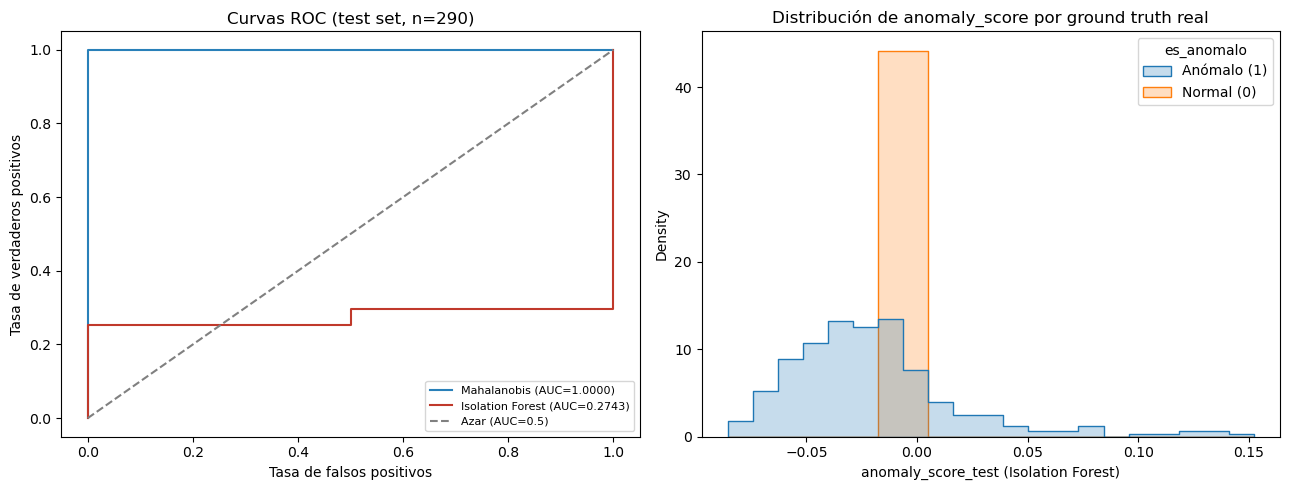

anomaly_score_test de los 2 ciclos normales: [-0.00606882 -0.00963804]
Percentil de cada uno dentro de la distribución completa de test (290 ciclos): ['74.5%', '70.0%']


In [5]:
import matplotlib.pyplot as plt  # no importado en la Sección 0 de este notebook — no hacía falta hasta ahora
import seaborn as sns  # idem
from sklearn.metrics import roc_curve  # curva completa, no solo el AUC ya calculado en la Sección 3

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"  # misma carpeta que 01_eda.ipynb y 02_feature_engineering.ipynb
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: curvas ROC de los dos detectores, superpuestas ──
fpr_maha, tpr_maha, _ = roc_curve(y_test_anomaly, maha2_test)
fpr_if, tpr_if, _ = roc_curve(y_test_anomaly, anomaly_score_test)

axes[0].plot(fpr_maha, tpr_maha, label=f"Mahalanobis (AUC={auc_maha:.4f})", color="#2980b9")
axes[0].plot(fpr_if, tpr_if, label=f"Isolation Forest (AUC={auc_if:.4f})", color="#c0392b")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC=0.5)")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curvas ROC (test set, n=290)")
axes[0].legend(fontsize=8, loc="lower right")

# ── Panel B: distribución de anomaly_score_test (Isolation Forest), separada por el ground truth real ──
plot_df = pd.DataFrame({
    "anomaly_score": anomaly_score_test,
    "es_anomalo": pd.Series(y_test_anomaly).map({0: "Normal (0)", 1: "Anómalo (1)"}),
})
sns.histplot(data=plot_df, x="anomaly_score", hue="es_anomalo", element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_xlabel("anomaly_score_test (Isolation Forest)")
axes[1].set_title("Distribución de anomaly_score por ground truth real")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_roc_and_score_distribution.png", bbox_inches="tight")
plt.show()

# ── Posición de los 2 ciclos normales dentro de la distribución de anomaly_score_test ──
scores_normal = anomaly_score_test[y_test_anomaly == 0]
percentile_ranks = [100 * (anomaly_score_test < s).mean() for s in scores_normal]
print(f"anomaly_score_test de los 2 ciclos normales: {scores_normal}")
print(f"Percentil de cada uno dentro de la distribución completa de test (290 ciclos): {[f'{p:.1f}%' for p in percentile_ranks]}")


### Interpretación

**El panel A hace visible, de un vistazo, la diferencia cualitativa entre los dos AUC ya reportados en la Sección 3.** La curva de Mahalanobis sube prácticamente en línea recta hacia la esquina superior izquierda —consistente con AUC=1.0000— porque los 2 ciclos normales de test tienen, literalmente, las dos puntuaciones más bajas de los 290. La curva de Isolation Forest, en cambio, discurre por **debajo** de la diagonal de azar en la mayor parte de su recorrido —consistente con AUC=0.2743—, no apenas por debajo de 0.5: es una curva sistemáticamente invertida, la señal visual de que el score se mueve en la dirección contraria a la etiqueta real, no de que sea simplemente poco informativo.

**El panel B cuantifica exactamente cuánto: los 2 ciclos normales de test tienen `anomaly_score_test` de -0.0061 y -0.0096, situados en los percentiles 74.5% y 70.0% de la distribución completa de los 290 ciclos.** En otras palabras, entre el 70% y el 75% de los ciclos de test —la gran mayoría de ellos con al menos un componente degradado— reciben una puntuación de anomalía **menor** (más "normal" según el modelo) que los 2 ciclos genuinamente sanos. Si Isolation Forest estuviera capturando salud del sistema, ambos deberían aparecer cerca del percentil 0% (el extremo de mínima anomalía); en cambio, aparecen en el tercio superior de la distribución. El histograma del panel B lo confirma visualmente: las dos curvas de densidad (normal vs. anómalo) se solapan casi por completo, sin que la curva "Normal" esté desplazada hacia valores bajos como cabría esperar de un detector de anomalías bien calibrado.

**Ambas figuras son la misma evidencia que la Sección 3 ya había cuantificado (AUC=1.0000 / 0.2743), presentada de forma visual — no añaden un hallazgo nuevo, lo hacen legible sin tener que interpretar dos números aislados.** Quedan guardadas en `reports/figures/03_roc_and_score_distribution.png` para referencia visual del proyecto, junto a las 4 figuras del EDA y el heatmap de η² de la Fase 2.
